# Notebook 11 — XAI SHAP: Metadata Feature Importance

## Goal

Explain the contribution of clinical variables (metadata) to the multimodal system predictions using **SHAP (SHapley Additive exPlanations)**.

## Models used

| Model | Metadata | Metadata dim | Why |
|-------|----------|-------------|-----|
| `multimodal_b0_none_localization_fold0` | anatomical localization | 15 | Best Recall Melanoma (0.7976) — primary model |
| `multimodal_b0_none_sex_age_fold0` | sex + age | 4 | Best Recall BCC (0.8442) — secondary model |

## Why SHAP on the metadata branch

The MultimodalModel uses a Late Fusion architecture:
- Image branch: EfficientNet-B0 → 1280-dim features
- Metadata branch: MLP → 32-dim features
- Fusion: concat(1312) → FC(256) → FC(7)

Applying SHAP on the full model would require explaining both image pixels and metadata simultaneously, which is computationally infeasible. Instead, we fix the image features (using the test set mean as baseline) and explain only the contribution of clinical metadata features.

## Notebook structure

| Part | Content |
|------|---------|
| 0 | Imports, setup, data and model loading |
| 1 | Global SHAP — localization model (beeswarm + bar plot) |
| 2 | Per-class examples — waterfall plots (1 sample per class × 7 classes) |
| 3 | Clinical cases — correct_melanoma, correct_non_mel, critical_error |
| 4 | Agreement vs Disagreement — SHAP comparison between both models |


---
## Part 0 — Imports, setup, data and model loading

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import shap

from torch.utils.data import DataLoader

sys.path.append('../src')
from config import (
    MODELS_DIR, METRICS_DIR, FIGURES_DIR, SPLITS_DIR,
    CLASSES, NUM_CLASSES, CLASS_TO_IDX, IDX_TO_CLASS, CLASS_NAMES_FULL
)
from model import MultimodalModel
from dataset import MultimodalSkinLesionDataset, load_test_multimodal
from transforms import get_val_transforms

# Reproducibility
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'SHAP version: {shap.__version__}')

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Device: cuda
SHAP version: 0.44.1


A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.


In [2]:
# ── Notebook constants ────────────────────────────────────────────────────────
FOLD = 0  # Best fold for both models (argmax of fold_aucs in record.json)

MODEL_LOC_PATH    = os.path.join(MODELS_DIR, f'multimodal_b0_none_localization_fold{FOLD}.pth')
MODEL_SA_PATH     = os.path.join(MODELS_DIR, f'multimodal_b0_none_sex_age_fold{FOLD}.pth')

METADATA_COLS_LOC = ['localization']
METADATA_COLS_SA  = ['sex', 'age']

PREPROCESSING = 'none'
AGE_MEAN      = 51.9  # Mean age from fold 0 training set

MEL_IDX = CLASS_TO_IDX['mel']   # 4
BCC_IDX = CLASS_TO_IDX['bcc']   # 1

# Number of background samples for KernelExplainer
N_BACKGROUND = 100

print('MODEL_LOC_PATH:', MODEL_LOC_PATH)
print('MODEL_SA_PATH: ', MODEL_SA_PATH)
print('MEL_IDX:', MEL_IDX, '| BCC_IDX:', BCC_IDX)

MODEL_LOC_PATH: /home/maialen/skin_lesion_PFG/outputs/models/multimodal_b0_none_localization_fold0.pth
MODEL_SA_PATH:  /home/maialen/skin_lesion_PFG/outputs/models/multimodal_b0_none_sex_age_fold0.pth
MEL_IDX: 4 | BCC_IDX: 1


In [3]:
# ── Load test datasets ────────────────────────────────────────────────────────
val_transform = get_val_transforms()

test_dataset_loc = load_test_multimodal(
    preprocessing_mode=PREPROCESSING,
    metadata_cols=METADATA_COLS_LOC,
    val_transform=val_transform,
    age_mean=AGE_MEAN
)

test_dataset_sa = load_test_multimodal(
    preprocessing_mode=PREPROCESSING,
    metadata_cols=METADATA_COLS_SA,
    val_transform=val_transform,
    age_mean=AGE_MEAN
)

print(f'Test samples: {len(test_dataset_loc)}')
print(f'Metadata dim localization: {test_dataset_loc.get_metadata_dim()}')
print(f'Metadata dim sex_age:      {test_dataset_sa.get_metadata_dim()}')
print(f'LOC_CATEGORIES: {test_dataset_loc.LOC_CATEGORIES}')
print(f'SEX_CATEGORIES: {test_dataset_sa.SEX_CATEGORIES}')

Test samples: 1497
Metadata dim localization: 15
Metadata dim sex_age:      4
LOC_CATEGORIES: ['abdomen', 'acral', 'back', 'chest', 'ear', 'face', 'foot', 'genital', 'hand', 'lower extremity', 'neck', 'scalp', 'trunk', 'unknown', 'upper extremity']
SEX_CATEGORIES: ['male', 'female', 'unknown']


In [4]:
# ── Feature names for SHAP ────────────────────────────────────────────────────
LOC_FEATURE_NAMES     = test_dataset_loc.LOC_CATEGORIES          # 15 strings
SEX_AGE_FEATURE_NAMES = test_dataset_sa.SEX_CATEGORIES + ['age'] # 4 strings

print('LOC feature names:', LOC_FEATURE_NAMES)
print('SEX_AGE feature names:', SEX_AGE_FEATURE_NAMES)

LOC feature names: ['abdomen', 'acral', 'back', 'chest', 'ear', 'face', 'foot', 'genital', 'hand', 'lower extremity', 'neck', 'scalp', 'trunk', 'unknown', 'upper extremity']
SEX_AGE feature names: ['male', 'female', 'unknown', 'age']


In [5]:
# ── Load models ───────────────────────────────────────────────────────────────
metadata_dim_loc = test_dataset_loc.get_metadata_dim()  # 15
metadata_dim_sa  = test_dataset_sa.get_metadata_dim()   # 4

model_loc = MultimodalModel(
    metadata_dim=metadata_dim_loc,
    efficientnet_version='b0',
    pretrained=False
)
model_loc.load_state_dict(torch.load(MODEL_LOC_PATH, map_location=device))
model_loc = model_loc.to(device)
model_loc.eval()

model_sa = MultimodalModel(
    metadata_dim=metadata_dim_sa,
    efficientnet_version='b0',
    pretrained=False
)
model_sa.load_state_dict(torch.load(MODEL_SA_PATH, map_location=device))
model_sa = model_sa.to(device)
model_sa.eval()

print('model_loc loaded — metadata_dim:', metadata_dim_loc)
print('model_sa  loaded — metadata_dim:', metadata_dim_sa)

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


model_loc loaded — metadata_dim: 15
model_sa  loaded — metadata_dim: 4


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [41]:
# ── Extract all test set data ─────────────────────────────────────────────────
# Load images, metadata and labels for all 1497 samples

def extract_test_data(dataset):
    """
    Extract images, metadata and labels from a MultimodalSkinLesionDataset.
    Returns:
        images:   np.ndarray (N, 3, 224, 224) — normalized tensors
        metadata: np.ndarray (N, metadata_dim)
        labels:   np.ndarray (N,)
    """
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)
    all_images   = []
    all_metadata = []
    all_labels   = []

    with torch.no_grad():
        for images, metadata, labels in loader:
            all_images.append(images.numpy())
            all_metadata.append(metadata.numpy())
            all_labels.append(labels.numpy())

    return (
        np.concatenate(all_images,   axis=0),
        np.concatenate(all_metadata, axis=0),
        np.concatenate(all_labels,   axis=0)
    )

images_loc, metadata_loc, labels_loc = extract_test_data(test_dataset_loc)
images_sa,  metadata_sa,  labels_sa  = extract_test_data(test_dataset_sa)

print(f'images_loc:   {images_loc.shape}')
print(f'metadata_loc: {metadata_loc.shape}')
print(f'labels_loc:   {labels_loc.shape}')
print(f'metadata_sa:  {metadata_sa.shape}')

# Verify labels match between both datasets
assert np.array_equal(labels_loc, labels_sa), 'ERROR: labels do not match between datasets'
labels = labels_loc  # common alias
print('Labels match: OK')

images_loc:   (1497, 3, 224, 224)
metadata_loc: (1497, 15)
labels_loc:   (1497,)
metadata_sa:  (1497, 4)
Labels match: OK


In [7]:
# ── Precompute image features ─────────────────────────────────────────────────
# Extract 1280-dim backbone features for all samples.
# This avoids OOM during SHAP (no need to pass images on every call).

def get_image_features(model, images_array, device, batch_size=64):
    """
    Extract image features using model.backbone for all samples.
    Args:
        model:        MultimodalModel in eval mode
        images_array: np.ndarray (N, 3, 224, 224)
        device:       torch.device
    Returns:
        np.ndarray (N, 1280)
    """
    all_features = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(images_array), batch_size):
            batch = torch.tensor(images_array[start:start+batch_size]).to(device)
            feats = model.backbone(batch)  # (B, 1280)
            all_features.append(feats.cpu().numpy())
    return np.concatenate(all_features, axis=0)

print('Extracting image features for model_loc...')
img_features_loc = get_image_features(model_loc, images_loc, device)
print(f'  img_features_loc: {img_features_loc.shape}')

print('Extracting image features for model_sa...')
img_features_sa = get_image_features(model_sa, images_sa, device)
print(f'  img_features_sa:  {img_features_sa.shape}')

# Mean image features: baseline for SHAP
mean_img_features_loc = img_features_loc.mean(axis=0, keepdims=True)  # (1, 1280)
mean_img_features_sa  = img_features_sa.mean(axis=0, keepdims=True)   # (1, 1280)

print(f'mean_img_features_loc: {mean_img_features_loc.shape}')
print(f'mean_img_features_sa:  {mean_img_features_sa.shape}')

Extracting image features for model_loc...
  img_features_loc: (1497, 1280)
Extracting image features for model_sa...
  img_features_sa:  (1497, 1280)
mean_img_features_loc: (1, 1280)
mean_img_features_sa:  (1, 1280)


In [8]:
# ── Prediction functions for SHAP ─────────────────────────────────────────────
# SHAP calls these functions with variable batch sizes.
# IMPORTANT: use n = len(metadata_array), do NOT hardcode len(metadata_loc)

def predict_fn_loc(metadata_array):
    """
    Prediction function for model_loc.
    Input:  metadata_array — np.ndarray (N, 15)
    Output: np.ndarray (N, 7) — softmax probabilities
    """
    n = len(metadata_array)
    img_feat = np.repeat(mean_img_features_loc, n, axis=0)  # (N, 1280)

    img_tensor  = torch.tensor(img_feat,       dtype=torch.float32).to(device)
    meta_tensor = torch.tensor(metadata_array, dtype=torch.float32).to(device)

    model_loc.eval()
    with torch.no_grad():
        meta_feat = model_loc.metadata_branch(meta_tensor)          # (N, 32)
        fused     = torch.cat([img_tensor, meta_feat], dim=1)       # (N, 1312)
        logits    = model_loc.classifier(fused)                     # (N, 7)
        probs     = torch.softmax(logits, dim=1)

    return probs.cpu().numpy()


def predict_fn_sa(metadata_array):
    """
    Prediction function for model_sa.
    Input:  metadata_array — np.ndarray (N, 4)
    Output: np.ndarray (N, 7) — softmax probabilities
    """
    n = len(metadata_array)
    img_feat = np.repeat(mean_img_features_sa, n, axis=0)   # (N, 1280)

    img_tensor  = torch.tensor(img_feat,       dtype=torch.float32).to(device)
    meta_tensor = torch.tensor(metadata_array, dtype=torch.float32).to(device)

    model_sa.eval()
    with torch.no_grad():
        meta_feat = model_sa.metadata_branch(meta_tensor)           # (N, 32)
        fused     = torch.cat([img_tensor, meta_feat], dim=1)       # (N, 1312)
        logits    = model_sa.classifier(fused)                      # (N, 7)
        probs     = torch.softmax(logits, dim=1)

    return probs.cpu().numpy()


# Sanity check
test_out_loc = predict_fn_loc(metadata_loc[:4])
test_out_sa  = predict_fn_sa(metadata_sa[:4])
print(f'predict_fn_loc output shape: {test_out_loc.shape}')  # (4, 7)
print(f'predict_fn_sa  output shape: {test_out_sa.shape}')   # (4, 7)
print(f'Prob sums (loc): {test_out_loc.sum(axis=1)}')
print(f'Prob sums (sa):  {test_out_sa.sum(axis=1)}')

predict_fn_loc output shape: (4, 7)
predict_fn_sa  output shape: (4, 7)
Prob sums (loc): [1.         1.         0.99999994 0.99999994]
Prob sums (sa):  [1.0000001  1.0000001  0.99999994 0.99999994]


In [9]:
# ── Load precomputed probabilities (from nb07) ────────────────────────────────
loc_probs = np.load(os.path.join(METRICS_DIR, 'std_probs_localization.npy'))  # (1497, 7)
sa_probs  = np.load(os.path.join(METRICS_DIR, 'std_probs_sex_age.npy'))       # (1497, 7)

loc_preds = np.argmax(loc_probs, axis=1)  # (1497,)
sa_preds  = np.argmax(sa_probs,  axis=1)  # (1497,)

print(f'loc_probs: {loc_probs.shape}')
print(f'sa_probs:  {sa_probs.shape}')

loc_probs: (1497, 7)
sa_probs:  (1497, 7)


## Part 1 - Global SHAP: localization model

We use SHAP's **KernelExplainer** to estimate the contribution of each anatomical localization feature to the model's predictions.

- **Background:** 100 random samples from the test set (baseline for KernelExplainer)
- **Explain:** all 1497 test set samples
- **Output:** `shap_values_loc` — list of 7 arrays (one per class), each of shape (1497, 15)

**Visualizations:**
1. Beeswarm plot — global feature importance (spread of SHAP values)
2. Bar plot — mean absolute SHAP value per feature

In [10]:
# ── KernelExplainer — localization model ─────────────────────────────────────
np.random.seed(42)
background_idx = np.random.choice(len(metadata_loc), size=N_BACKGROUND, replace=False)
background_loc = metadata_loc[background_idx]  # (100, 15)

print(f'Background shape: {background_loc.shape}')
print('Creating KernelExplainer for model_loc...')
explainer_loc = shap.KernelExplainer(predict_fn_loc, background_loc)

print('Computing SHAP values for all 1497 samples...')
print('(This step may take several minutes)')
shap_values_loc = explainer_loc.shap_values(metadata_loc, silent=False)
# shap_values_loc: list of 7 arrays, each (1497, 15)

print(f'\nshap_values_loc type: {type(shap_values_loc)}')
print(f'Number of classes: {len(shap_values_loc)}')
print(f'Shape per class:   {shap_values_loc[0].shape}')

Background shape: (100, 15)
Creating KernelExplainer for model_loc...
Computing SHAP values for all 1497 samples...
(This step may take several minutes)


100%|██████████| 1497/1497 [15:53<00:00,  1.57it/s]


shap_values_loc type: <class 'list'>
Number of classes: 7
Shape per class:   (1497, 15)


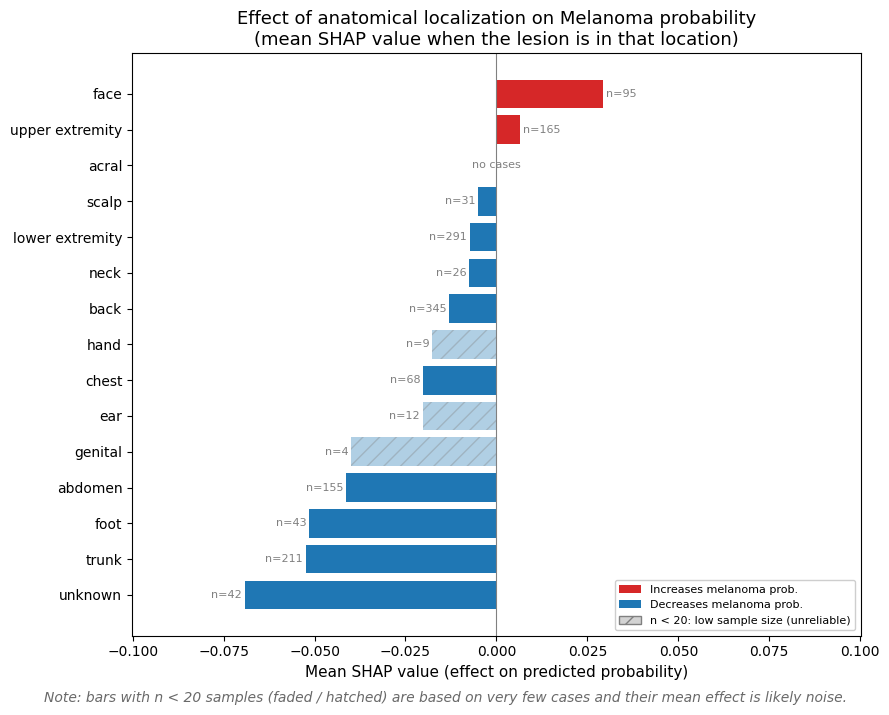

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_localization_effect_melanoma.png


In [25]:
# ── Diverging bar plot — Mean signed SHAP effect (localization, melanoma class) ─
# More intuitive than a beeswarm for one-hot features: for each anatomical zone,
# it shows the average effect on the predicted melanoma probability among
# patients whose lesion IS located there (feature == 1).
from matplotlib.patches import Patch

def plot_signed_effect(shap_values_class, metadata, feature_names, title, save_name,
                       min_reliable_n=20, figsize=(9, 7)):
    """
    For each one-hot feature, compute the mean SHAP value among samples where
    that feature is active (feature == 1). This represents the average effect
    of "having the lesion in this location" on the predicted probability for
    the given class.

    Bars built from fewer than `min_reliable_n` samples are faded and hatched,
    because their mean effect is dominated by sampling noise.

    Args:
        shap_values_class: np.ndarray (N, n_features) — SHAP values for one class
        metadata:          np.ndarray (N, n_features) — one-hot metadata
        feature_names:     list of str (n_features,)
        title:             plot title
        save_name:         filename to save in FIGURES_DIR
        min_reliable_n:    bars with n < this are marked as unreliable
        figsize:           figure size

    Returns:
        mean_effect: np.ndarray (n_features,) — mean SHAP value per feature
        n_samples:   np.ndarray (n_features,) — number of active samples per feature
    """
    n_features  = metadata.shape[1]
    mean_effect = np.full(n_features, np.nan)
    n_samples   = np.zeros(n_features, dtype=int)

    for j in range(n_features):
        mask = metadata[:, j] == 1
        n_samples[j] = mask.sum()
        if mask.sum() > 0:
            mean_effect[j] = shap_values_class[mask, j].mean()

    order = np.argsort(np.nan_to_num(mean_effect, nan=0))
    sorted_names  = [feature_names[i] for i in order]
    sorted_values = mean_effect[order]
    sorted_n      = n_samples[order]

    # Per-bar style: color by sign of the effect; fade + hatch when n < min_reliable_n
    colors, alphas, hatches = [], [], []
    for v, n in zip(sorted_values, sorted_n):
        if np.isnan(v):
            colors.append('lightgray'); alphas.append(0.30); hatches.append('//'); continue
        colors.append('#d62728' if v > 0 else '#1f77b4')
        if n < min_reliable_n:
            alphas.append(0.35); hatches.append('//')   # unreliable: low sample size
        else:
            alphas.append(1.0);  hatches.append(None)

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(sorted_names, np.nan_to_num(sorted_values), color=colors)
    for bar, a, h in zip(bars, alphas, hatches):
        bar.set_alpha(a)
        if h:
            bar.set_hatch(h)
            bar.set_edgecolor('gray')
            bar.set_linewidth(0.0)

    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_xlabel('Mean SHAP value (effect on predicted probability)', fontsize=11)
    ax.set_title(title, fontsize=13)

    # Headroom on both sides so the n= labels never get clipped
    xmax = np.nanmax(np.abs(sorted_values))
    ax.set_xlim(-xmax * 1.45, xmax * 1.45)
    off = xmax * 0.012

    for bar, n, v in zip(bars, sorted_n, sorted_values):
        if np.isnan(v):
            ax.text(0, bar.get_y() + bar.get_height() / 2, 'no cases',
                    va='center', ha='center', fontsize=8, color='gray')
            continue
        x = bar.get_width()
        ax.text(
            x + (off if x >= 0 else -off),
            bar.get_y() + bar.get_height() / 2,
            f'n={n}', va='center',
            ha='left' if x >= 0 else 'right',
            fontsize=8, color='gray'
        )

    legend_elements = [
        Patch(facecolor='#d62728', label='Increases melanoma prob.'),
        Patch(facecolor='#1f77b4', label='Decreases melanoma prob.'),
        Patch(facecolor='lightgray', hatch='//', edgecolor='gray',
              label=f'n < {min_reliable_n}: low sample size (unreliable)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.95)

    fig.text(0.5, -0.01,
             f'Note: bars with n < {min_reliable_n} samples (faded / hatched) are based on very '
             f'few cases and their mean effect is likely noise.',
             ha='center', fontsize=10, style='italic', color='dimgray')

    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, save_name)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

    return mean_effect, n_samples


# Diverging bar plot for the melanoma class (most clinically relevant)
mean_effect_mel, n_samples_mel = plot_signed_effect(
    shap_values_loc[MEL_IDX],
    metadata_loc,
    LOC_FEATURE_NAMES,
    title='Effect of anatomical localization on Melanoma probability\n'
          '(mean SHAP value when the lesion is in that location)',
    save_name='shap_localization_effect_melanoma.png',
    min_reliable_n=20
)

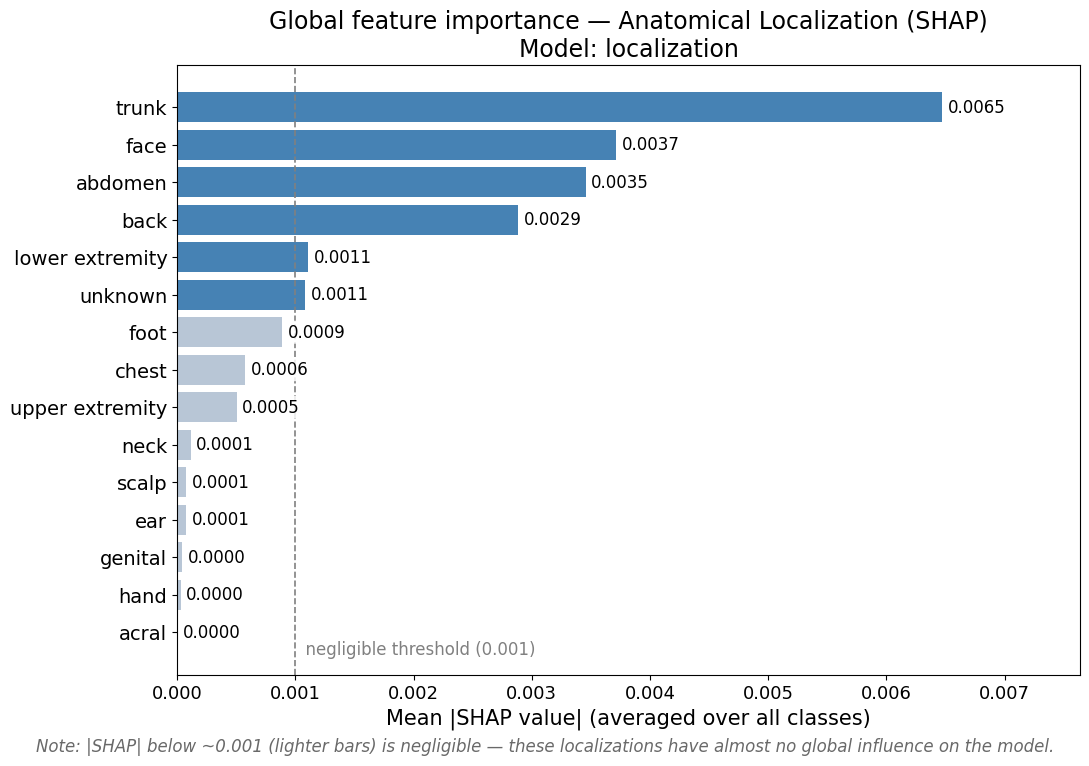

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_global_bar.png


In [38]:
# ── Bar plot — Mean absolute SHAP (localization, all classes) ─────────────────

shap_values_stacked = np.stack(shap_values_loc, axis=0)               # (7, 1497, 15)
mean_abs_shap       = np.mean(np.abs(shap_values_stacked), axis=(0, 1))  # (15,)
sorted_idx          = np.argsort(mean_abs_shap)[::-1]

NEGLIGIBLE = 0.001  # below this, mean|SHAP| is practically zero (numerical noise)

names_sorted = [LOC_FEATURE_NAMES[i] for i in sorted_idx]
vals_sorted  = mean_abs_shap[sorted_idx]
bar_colors   = ['steelblue' if v >= NEGLIGIBLE else '#b8c6d6' for v in vals_sorted]

fig, ax = plt.subplots(figsize=(11, 7.5))
bars = ax.barh(names_sorted, vals_sorted, color=bar_colors)
ax.invert_yaxis()

# Negligible threshold guide line + label
ax.axvline(NEGLIGIBLE, color='gray', linestyle='--', linewidth=1.2)
ax.text(NEGLIGIBLE, len(names_sorted) - 0.3, f'  negligible threshold ({NEGLIGIBLE})',
        color='gray', fontsize=12, va='bottom', ha='left')

ax.set_xlabel('Mean |SHAP value| (averaged over all classes)', fontsize=15)
ax.set_title('Global feature importance — Anatomical Localization (SHAP)\nModel: localization',
             fontsize=17)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=13)

# Value labels with white background so they stay readable over the dashed line
bar_value_labels = ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=12)
for lbl in bar_value_labels:
    lbl.set_bbox(dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.85))

ax.margins(x=0.18)  # headroom so the value labels don't clip

fig.text(0.5, -0.01,
         f'Note: |SHAP| below ~{NEGLIGIBLE} (lighter bars) is negligible — these localizations '
         f'have almost no global influence on the model.',
         ha='center', fontsize=12, style='italic', color='dimgray')

plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'shap_global_bar.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

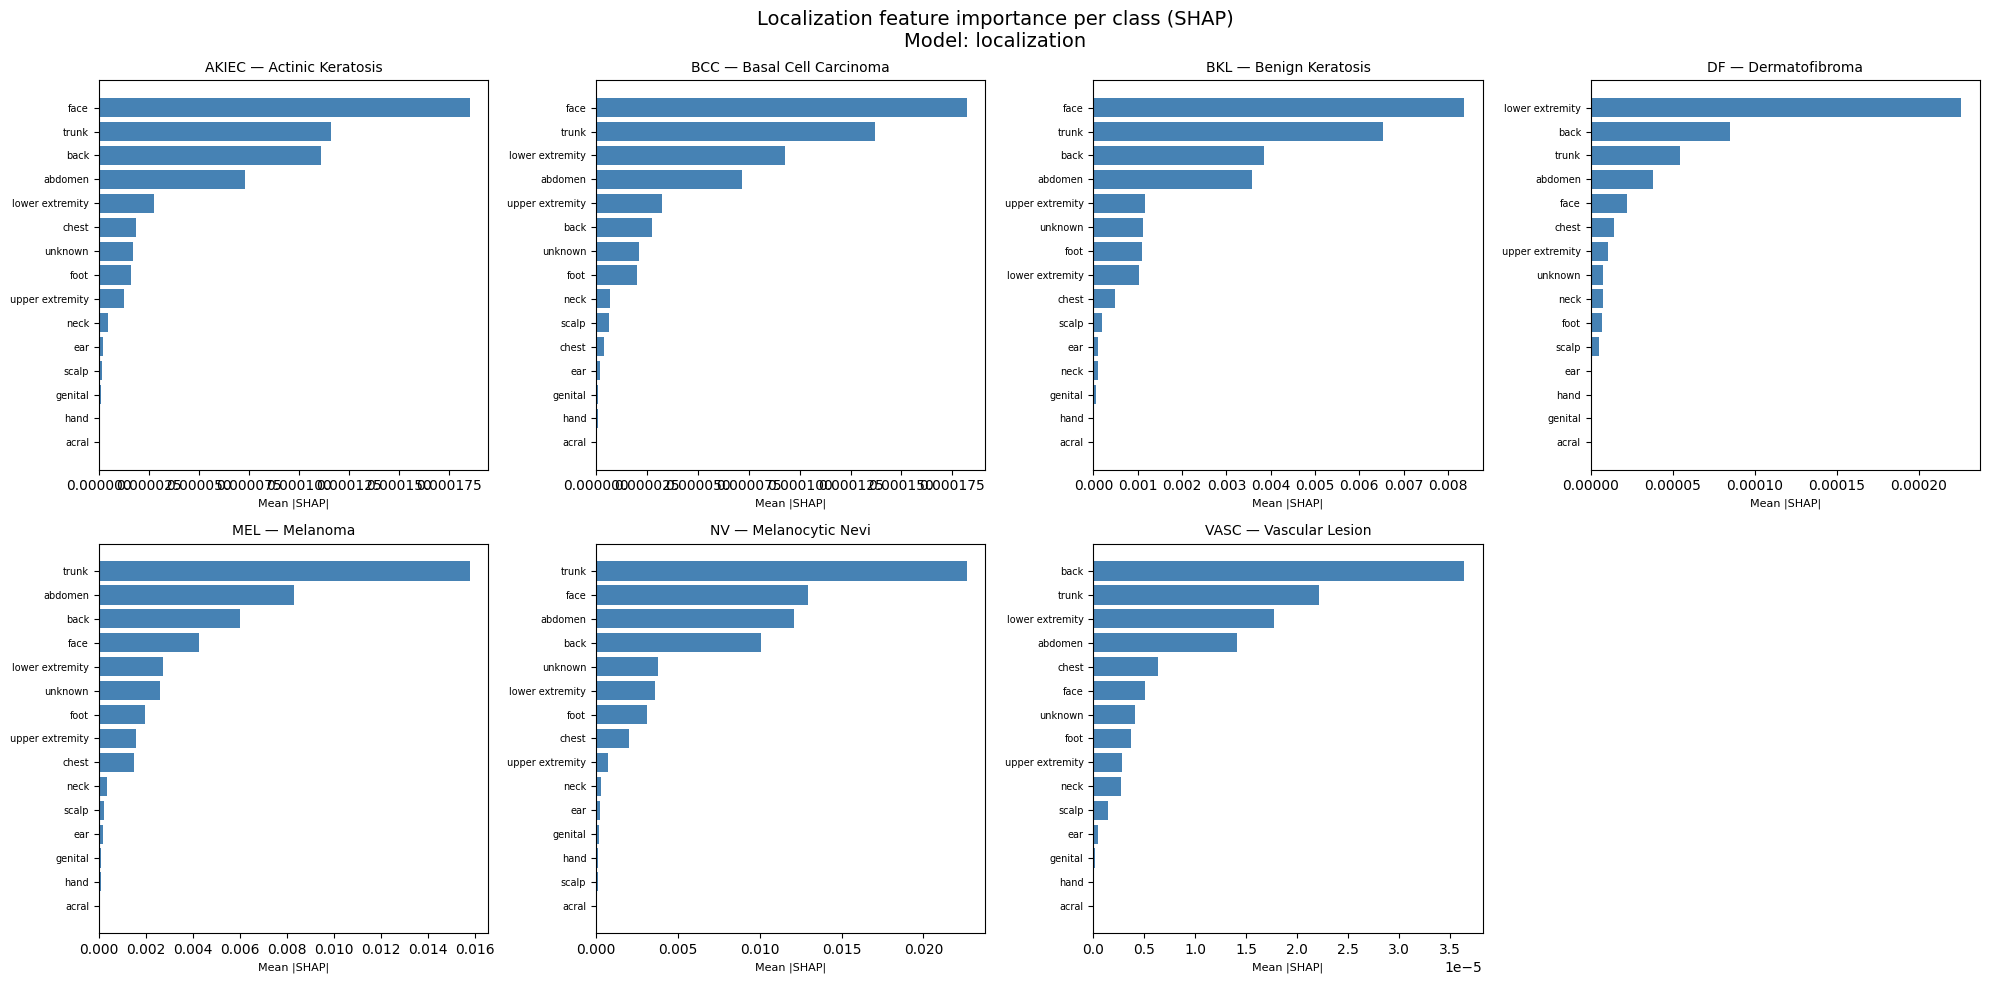

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_global_by_class.png


In [39]:
# ── Bar plot per class — localization importance for each diagnosis ────────────

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for class_idx, class_name in enumerate(CLASSES):
    mean_abs = np.mean(np.abs(shap_values_loc[class_idx]), axis=0)  # (15,)
    sorted_i = np.argsort(mean_abs)[::-1]

    ax = axes[class_idx]
    ax.barh(
        [LOC_FEATURE_NAMES[i] for i in sorted_i],
        mean_abs[sorted_i],
        color='steelblue'
    )
    ax.invert_yaxis()
    ax.set_title(f'{class_name.upper()} — {CLASS_NAMES_FULL[class_name]}', fontsize=10)
    ax.set_xlabel('Mean |SHAP|', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)

# Hide the extra subplot (7 classes in 8 cells)
axes[7].set_visible(False)

fig.suptitle('Localization feature importance per class (SHAP)\nModel: localization', fontsize=14)
plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'shap_global_by_class.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

Mean of empty slice


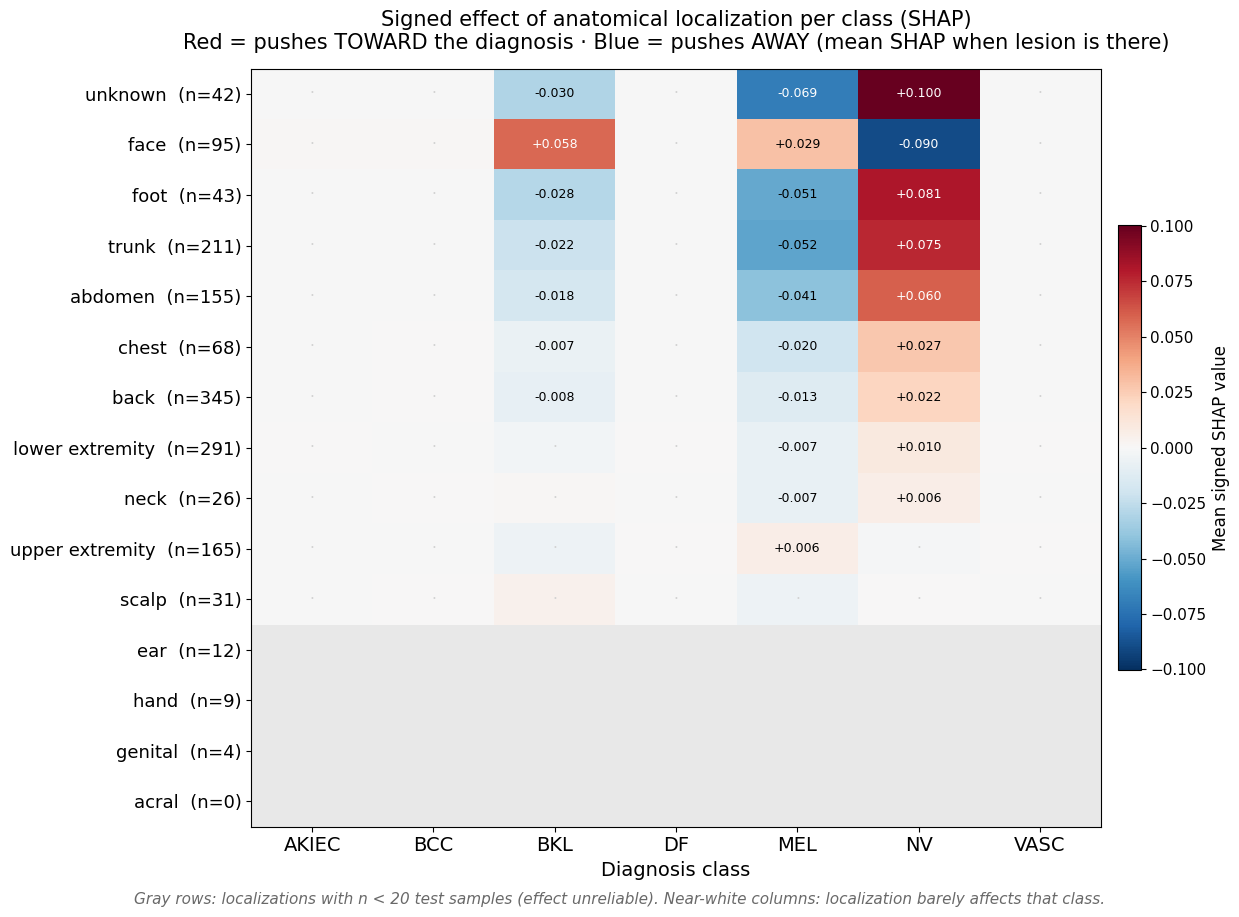

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_localization_per_class_heatmap.png


In [40]:
# ── Heatmap — Signed effect of localization per class (replaces 8 cramped bar plots) ─
# For each (localization, class): mean SHAP value among patients whose lesion IS in
# that location. Red = being there pushes TOWARD that diagnosis, blue = AWAY.

MIN_N = 20  # localizations with fewer test samples are flagged as unreliable

n_features = metadata_loc.shape[1]   # 15
n_classes  = len(CLASSES)            # 7

# Signed-effect matrix (n_features, n_classes) + active-sample count per localization
effect   = np.full((n_features, n_classes), np.nan)
n_active = np.zeros(n_features, dtype=int)
for j in range(n_features):
    mask = metadata_loc[:, j] == 1
    n_active[j] = mask.sum()
    if mask.sum() > 0:
        for c in range(n_classes):
            effect[j, c] = shap_values_loc[c][mask, j].mean()

reliable = n_active >= MIN_N

# Row order: reliable rows by importance (desc), unreliable rows grouped at the bottom
importance = np.nan_to_num(np.nanmean(np.abs(effect), axis=1))
rel_idx   = [i for i in np.argsort(importance)[::-1] if reliable[i]]
unrel_idx = [i for i in np.argsort(n_active)[::-1]   if not reliable[i]]
order     = rel_idx + unrel_idx

effO  = effect[order]
LOCo  = [LOC_FEATURE_NAMES[i] for i in order]
nO    = n_active[order]
relO  = reliable[order]

# Mask unreliable rows for coloring (shown gray)
plot_mat = effO.copy()
plot_mat[~relO] = np.nan
vmax = np.nanmax(np.abs(plot_mat))

fig, ax = plt.subplots(figsize=(12.5, 9))
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad('#e8e8e8')   # gray for masked (unreliable) rows
im = ax.imshow(plot_mat, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(n_classes))
ax.set_xticklabels([c.upper() for c in CLASSES], fontsize=14)
ax.set_yticks(range(n_features))
ax.set_yticklabels([f'{l}  (n={n})' for l, n in zip(LOCo, nO)], fontsize=13)

# Cell annotations
for i in range(n_features):
    for j in range(n_classes):
        if relO[i]:
            v = effO[i, j]
            if abs(v) < 0.005:
                ax.text(j, i, '·', ha='center', va='center', fontsize=11, color='lightgray')
            else:
                col = 'white' if abs(v) > vmax * 0.55 else 'black'
                ax.text(j, i, f'{v:+.3f}', ha='center', va='center', fontsize=9, color=col)
                
ax.set_title('Signed effect of anatomical localization per class (SHAP)\n'
             'Red = pushes TOWARD the diagnosis · Blue = pushes AWAY '
             '(mean SHAP when lesion is there)', fontsize=15, pad=14)
ax.set_xlabel('Diagnosis class', fontsize=14)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Mean signed SHAP value', fontsize=12)
cbar.ax.tick_params(labelsize=11)

fig.text(0.5, -0.01,
         f'Gray rows: localizations with n < {MIN_N} test samples (effect unreliable). '
         'Near-white columns: localization barely affects that class.',
         ha='center', fontsize=11, style='italic', color='dimgray')

plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'shap_localization_per_class_heatmap.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

**Note on shortcut learning:** the signed effects above tend to follow the
*frequency* of each localization in the training set rather than its true
clinical association with each class. For example, the model pushes trunk,
back and abdomen lesions toward *nv*, simply because these are the most
common nevus locations in HAM10000 — not because of a genuine diagnostic
signal. This frequency-driven behaviour is quantified in notebook 13
(SHAP importance vs training-set frequency), where its impact on the
system's errors is analysed.

## Part 2 — Clinical cases (localization model)

We explain individual clinically relevant predictions. Unlike the global analysis,
here the image is **fixed at each patient's REAL image features** (not the dataset
mean), so SHAP explains how the clinical metadata shifted *this specific prediction*.
The target class is always the **predicted class**, so SHAP reflects what the model
actually decided — including its mistakes.

| Case | Definition | Clinical meaning |
|------|-----------|------------------|
| TP | Melanoma predicted as melanoma | Correct detection |
| FN | Melanoma predicted as non-melanoma | Critical miss |
| FP | Non-melanoma predicted as melanoma | Unnecessary biopsy |
| TN | Non-melanoma correctly classified | Correct rule-out |

Red bars push **toward** the predicted class · blue bars push **away**.

In [42]:
# ── Select clinical cases (melanoma confusion-matrix quadrants) ───────────────
mel_mask     = labels == MEL_IDX
non_mel_mask = ~mel_mask
correct_mask = loc_preds == labels

clinical_cases = {}

# TP — melanoma correctly detected (most confident)
tp = np.where(mel_mask & (loc_preds == MEL_IDX))[0]
if len(tp):
    clinical_cases['TP — Melanoma correctly detected'] = int(tp[np.argmax(loc_probs[tp, MEL_IDX])])

# FN — melanoma missed (most confidently wrong)
fn = np.where(mel_mask & (loc_preds != MEL_IDX))[0]
if len(fn):
    clinical_cases['FN — Melanoma missed (critical error)'] = int(fn[np.argmax(loc_probs[fn, loc_preds[fn]])])

# FP — benign predicted as melanoma (unnecessary biopsy)
fp = np.where(non_mel_mask & (loc_preds == MEL_IDX))[0]
if len(fp):
    clinical_cases['FP — Benign predicted as melanoma'] = int(fp[np.argmax(loc_probs[fp, MEL_IDX])])

# TN — benign correctly classified (most confident correct rule-out)
tn = np.where(non_mel_mask & correct_mask)[0]
if len(tn):
    clinical_cases['TN — Benign correctly ruled out'] = int(tn[np.argmax(loc_probs[tn, labels[tn]])])

for name, idx in clinical_cases.items():
    print(f'{name:42s} idx={idx:4d} | true={CLASSES[labels[idx]]:5s} '
          f'pred={CLASSES[loc_preds[idx]]:5s} | P(mel)={loc_probs[idx, MEL_IDX]:.3f}')

TP — Melanoma correctly detected           idx= 200 | true=mel   pred=mel   | P(mel)=1.000
FN — Melanoma missed (critical error)      idx= 305 | true=mel   pred=akiec | P(mel)=0.001
FP — Benign predicted as melanoma          idx=  33 | true=bkl   pred=mel   | P(mel)=0.987
TN — Benign correctly ruled out            idx= 862 | true=nv    pred=nv    | P(mel)=0.000


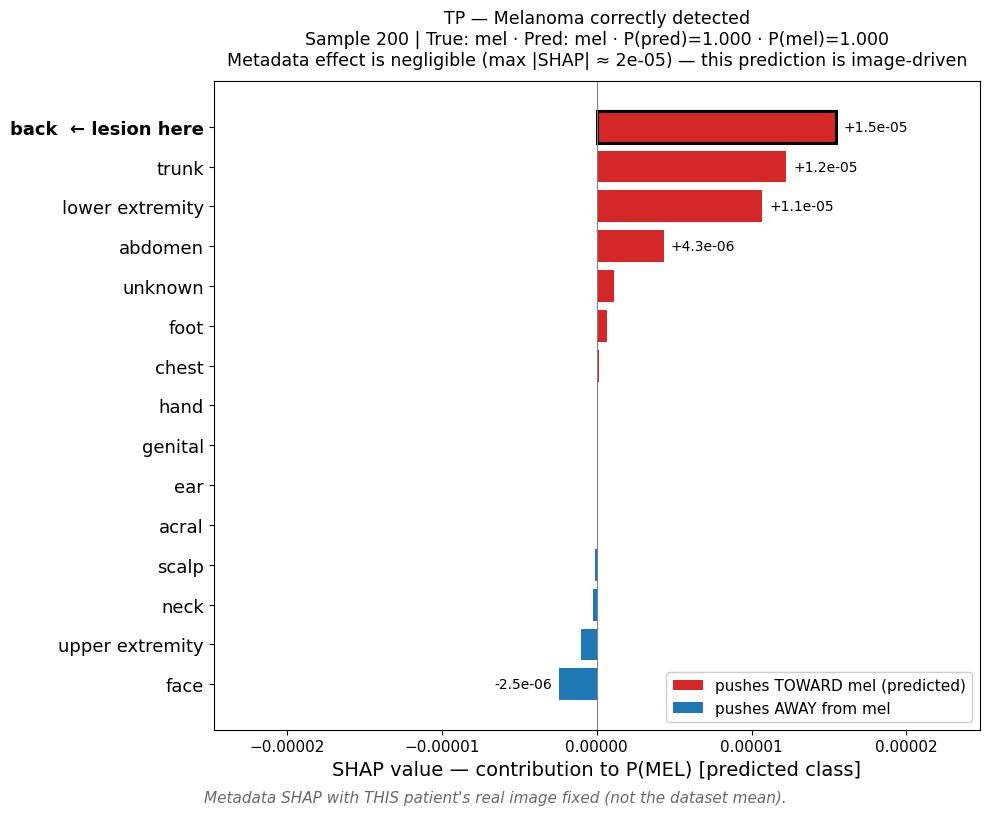

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_clinical_tp.png


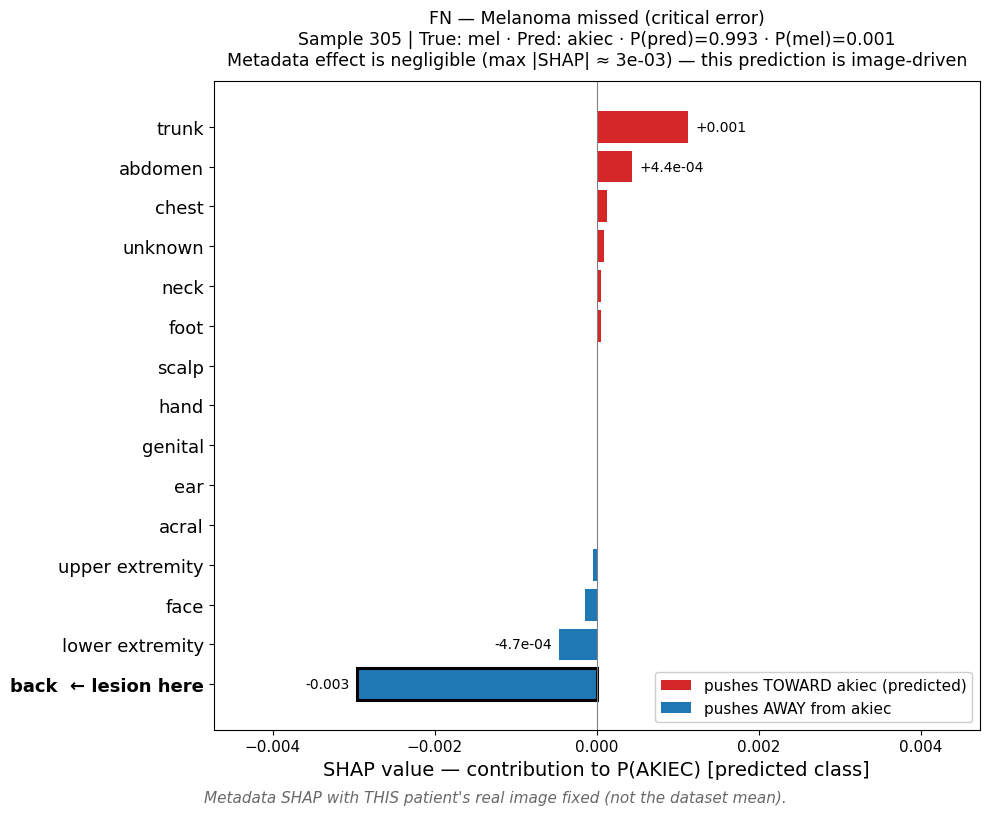

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_clinical_fn.png


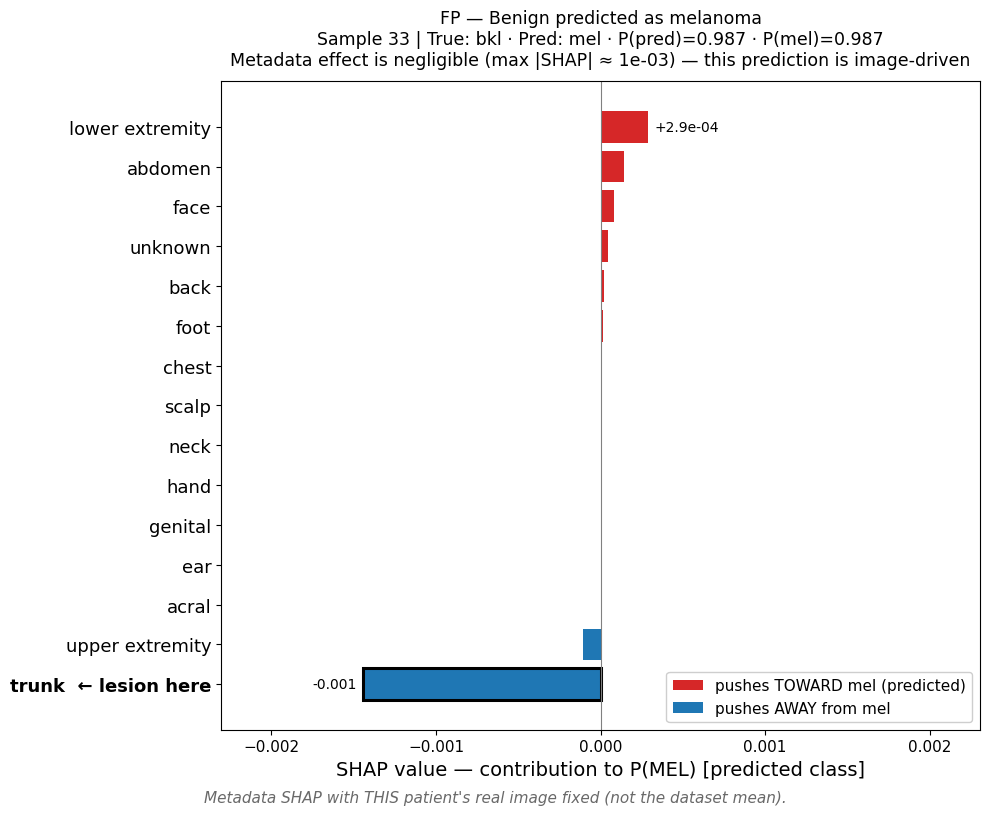

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_clinical_fp.png


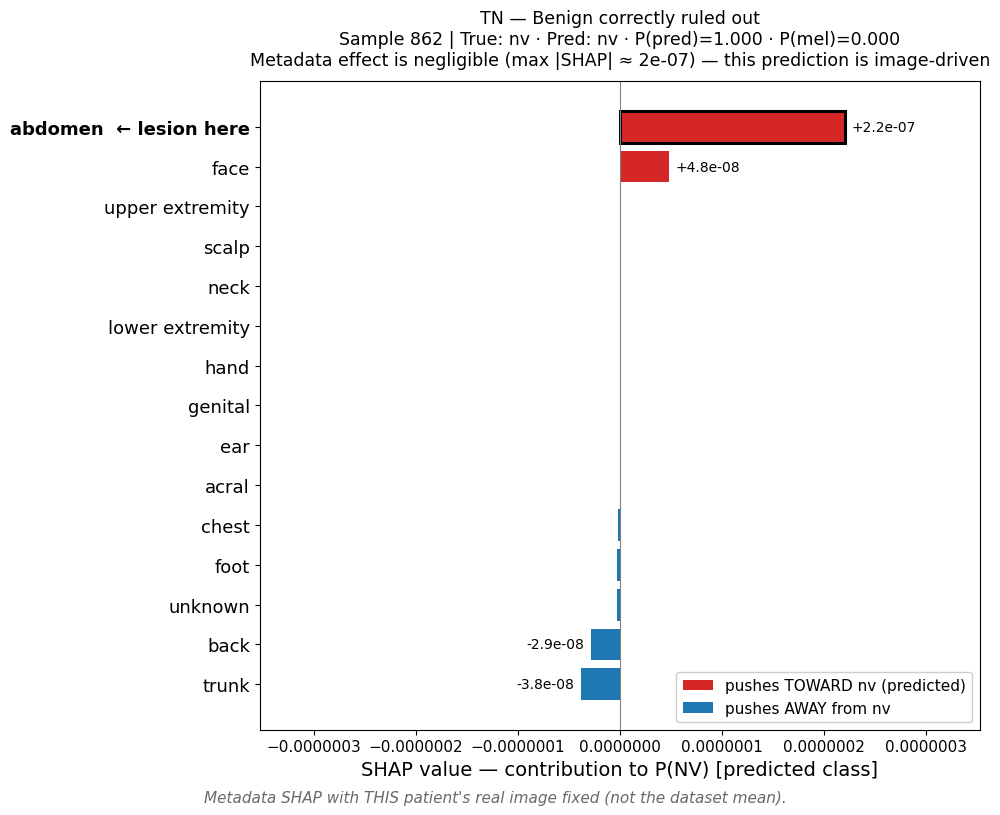

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_clinical_tn.png


In [44]:
# ── Per-case SHAP with the patient's REAL image fixed + signed barplot ────────
from matplotlib.patches import Patch

NEGLIGIBLE_CASE = 0.005   # if max|SHAP| < this, the metadata effect is negligible


def shap_case_real_image(idx, target_class, model, img_features, metadata,
                         background, device, nsamples='auto'):
    """
    SHAP of the metadata branch for ONE case, fixing the image at THIS patient's
    real backbone features (img_features[idx]) instead of the dataset mean.
    Returns (shap_values (n_features,), base_value, f(x) for target_class).
    """
    real_img = img_features[idx:idx + 1]                          # (1, 1280) real features

    def predict_fn(meta):
        n   = len(meta)
        img = torch.tensor(np.repeat(real_img, n, axis=0), dtype=torch.float32, device=device)
        mt  = torch.tensor(meta, dtype=torch.float32, device=device)
        model.eval()
        with torch.no_grad():
            mf    = model.metadata_branch(mt)
            probs = torch.softmax(model.classifier(torch.cat([img, mf], dim=1)), dim=1)
        return probs.cpu().numpy()

    expl = shap.KernelExplainer(predict_fn, background)
    sv   = expl.shap_values(metadata[idx:idx + 1], silent=True, nsamples=nsamples)
    shap_vals = sv[target_class][0] if isinstance(sv, list) else sv[0, :, target_class]
    base = np.atleast_1d(expl.expected_value)[target_class]
    fx   = predict_fn(metadata[idx:idx + 1])[0, target_class]
    return shap_vals, base, fx


def fmt_val(v):
    """Readable label: fixed-point for normal values, scientific for tiny ones."""
    return f'{v:+.3f}' if abs(v) >= 1e-3 else f'{v:+.1e}'


def plot_clinical_case(idx, case_title, save_name):
    target = int(loc_preds[idx])
    pred   = CLASSES[target]
    true   = CLASSES[int(labels[idx])]
    shap_vals, base, fx = shap_case_real_image(
        idx, target, model_loc, img_features_loc, metadata_loc, background_loc, device)

    active      = int(np.argmax(metadata_loc[idx]))      # the one-hot location == 1
    active_name = LOC_FEATURE_NAMES[active]
    active_val  = shap_vals[active]
    max_abs     = np.max(np.abs(shap_vals))
    negligible  = max_abs < NEGLIGIBLE_CASE

    order  = np.argsort(shap_vals)
    vals   = shap_vals[order]
    names  = [LOC_FEATURE_NAMES[i] for i in order]
    apos   = list(order).index(active)
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in vals]

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(range(len(vals)), vals, color=colors)
    ax.axvline(0, color='gray', lw=0.8)
    bars[apos].set_edgecolor('black'); bars[apos].set_linewidth(2.2)

    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels([f'{n}  ← lesion here' if i == apos else n
                        for i, n in enumerate(names)], fontsize=13)
    for i, lbl in enumerate(ax.get_yticklabels()):
        if i == apos:
            lbl.set_fontweight('bold')

    xmax = max(max_abs, 1e-9)
    ax.set_xlim(-xmax * 1.6, xmax * 1.6)
    for i, v in enumerate(vals):
        if abs(v) >= xmax * 0.12 or i == apos:
            ax.text(v + np.sign(v) * xmax * 0.03, i, fmt_val(v),
                    va='center', ha='left' if v > 0 else 'right', fontsize=10)

    # Plain x-axis numbers (avoid the dangling "1e-5" offset text)
    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
    ax.tick_params(axis='x', labelsize=11)

    subtitle = (f'Sample {idx} | True: {true} · Pred: {pred} · '
                f'P(pred)={fx:.3f} · P(mel)={loc_probs[idx, MEL_IDX]:.3f}')
    if negligible:
        third = (f'Metadata effect is negligible (max |SHAP| ≈ {max_abs:.0e}) — '
                 f'this prediction is image-driven')
    else:
        third = f'Lesion in "{active_name}" contributes {fmt_val(active_val)} to P({pred})'

    ax.set_xlabel(f'SHAP value — contribution to P({pred.upper()}) [predicted class]', fontsize=14)
    ax.set_title(f'{case_title}\n{subtitle}\n{third}', fontsize=12.5, pad=12)
    ax.legend(handles=[Patch(facecolor='#d62728', label=f'pushes TOWARD {pred} (predicted)'),
                       Patch(facecolor='#1f77b4', label=f'pushes AWAY from {pred}')],
              loc='lower right', fontsize=11, framealpha=0.95)
    fig.text(0.5, -0.01,
             "Metadata SHAP with THIS patient's real image fixed (not the dataset mean).",
             ha='center', fontsize=11, style='italic', color='dimgray')

    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, save_name)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


for case_title, idx in clinical_cases.items():
    tag = case_title.split(' ')[0].lower()         # tp / fn / fp / tn
    plot_clinical_case(idx, case_title, f'shap_clinical_{tag}.png')

## Part 3 — Agreement vs Disagreement between the two models

The final system is an **ensemble** of `localization` + `sex_age`. They agree on
most cases; when they **disagree**, the case is ambiguous. Here we show, for a few
disagreement cases, what each model's **metadata branch** contributed (with that
patient's real image fixed), to see what each branch "was looking at".

Note: since each model has its **own image backbone**, the disagreement is driven
mostly by the **image branches**, not the metadata. These panels show the (weak)
metadata contribution only; the image-level root cause is analysed in notebook 13.

In [46]:
# ── Agreement / disagreement stats + case selection ──────────────────────────
labels = np.asarray(labels)
agree_mask    = loc_preds == sa_preds
disagree_mask = ~agree_mask
disagree_idx  = np.where(disagree_mask)[0]

print(f'Agreement:    {agree_mask.sum():4d} / {len(labels)} ({100*agree_mask.mean():.1f}%)')
print(f'Disagreement: {disagree_mask.sum():4d} / {len(labels)} ({100*disagree_mask.mean():.1f}%)')

# Three representative disagreement cases (by which model was right)
loc_ok = loc_preds == labels
sa_ok  = sa_preds  == labels

cand_loc_wins   = disagree_idx[ loc_ok[disagree_idx] & ~sa_ok[disagree_idx]]
cand_sa_wins    = disagree_idx[~loc_ok[disagree_idx] &  sa_ok[disagree_idx]]
cand_both_wrong = disagree_idx[~loc_ok[disagree_idx] & ~sa_ok[disagree_idx]]

def most_confident(cands):
    """Pick the case where the disagreement is sharpest (max combined confidence)."""
    if len(cands) == 0:
        return None
    score = loc_probs[cands, loc_preds[cands]] + sa_probs[cands, sa_preds[cands]]
    return int(cands[np.argmax(score)])

disagreement_cases = {}
for title, cands in [
    ('Localization correct · Sex+Age wrong', cand_loc_wins),
    ('Sex+Age correct · Localization wrong', cand_sa_wins),
    ('Both models wrong',                    cand_both_wrong),
]:
    idx = most_confident(cands)
    if idx is not None:
        disagreement_cases[title] = idx

print(f'\nloc wins: {len(cand_loc_wins)} | sa wins: {len(cand_sa_wins)} | both wrong: {len(cand_both_wrong)}')
for t, i in disagreement_cases.items():
    print(f'  {t:42s} idx={i:4d} | true={CLASSES[labels[i]]:5s} '
          f'loc={CLASSES[loc_preds[i]]:5s} sa={CLASSES[sa_preds[i]]:5s}')

Agreement:    1304 / 1497 (87.1%)
Disagreement:  193 / 1497 (12.9%)

loc wins: 66 | sa wins: 99 | both wrong: 28
  Localization correct · Sex+Age wrong       idx= 606 | true=nv    loc=nv    sa=df   
  Sex+Age correct · Localization wrong       idx= 176 | true=df    loc=nv    sa=df   
  Both models wrong                          idx= 320 | true=mel   loc=bcc   sa=akiec


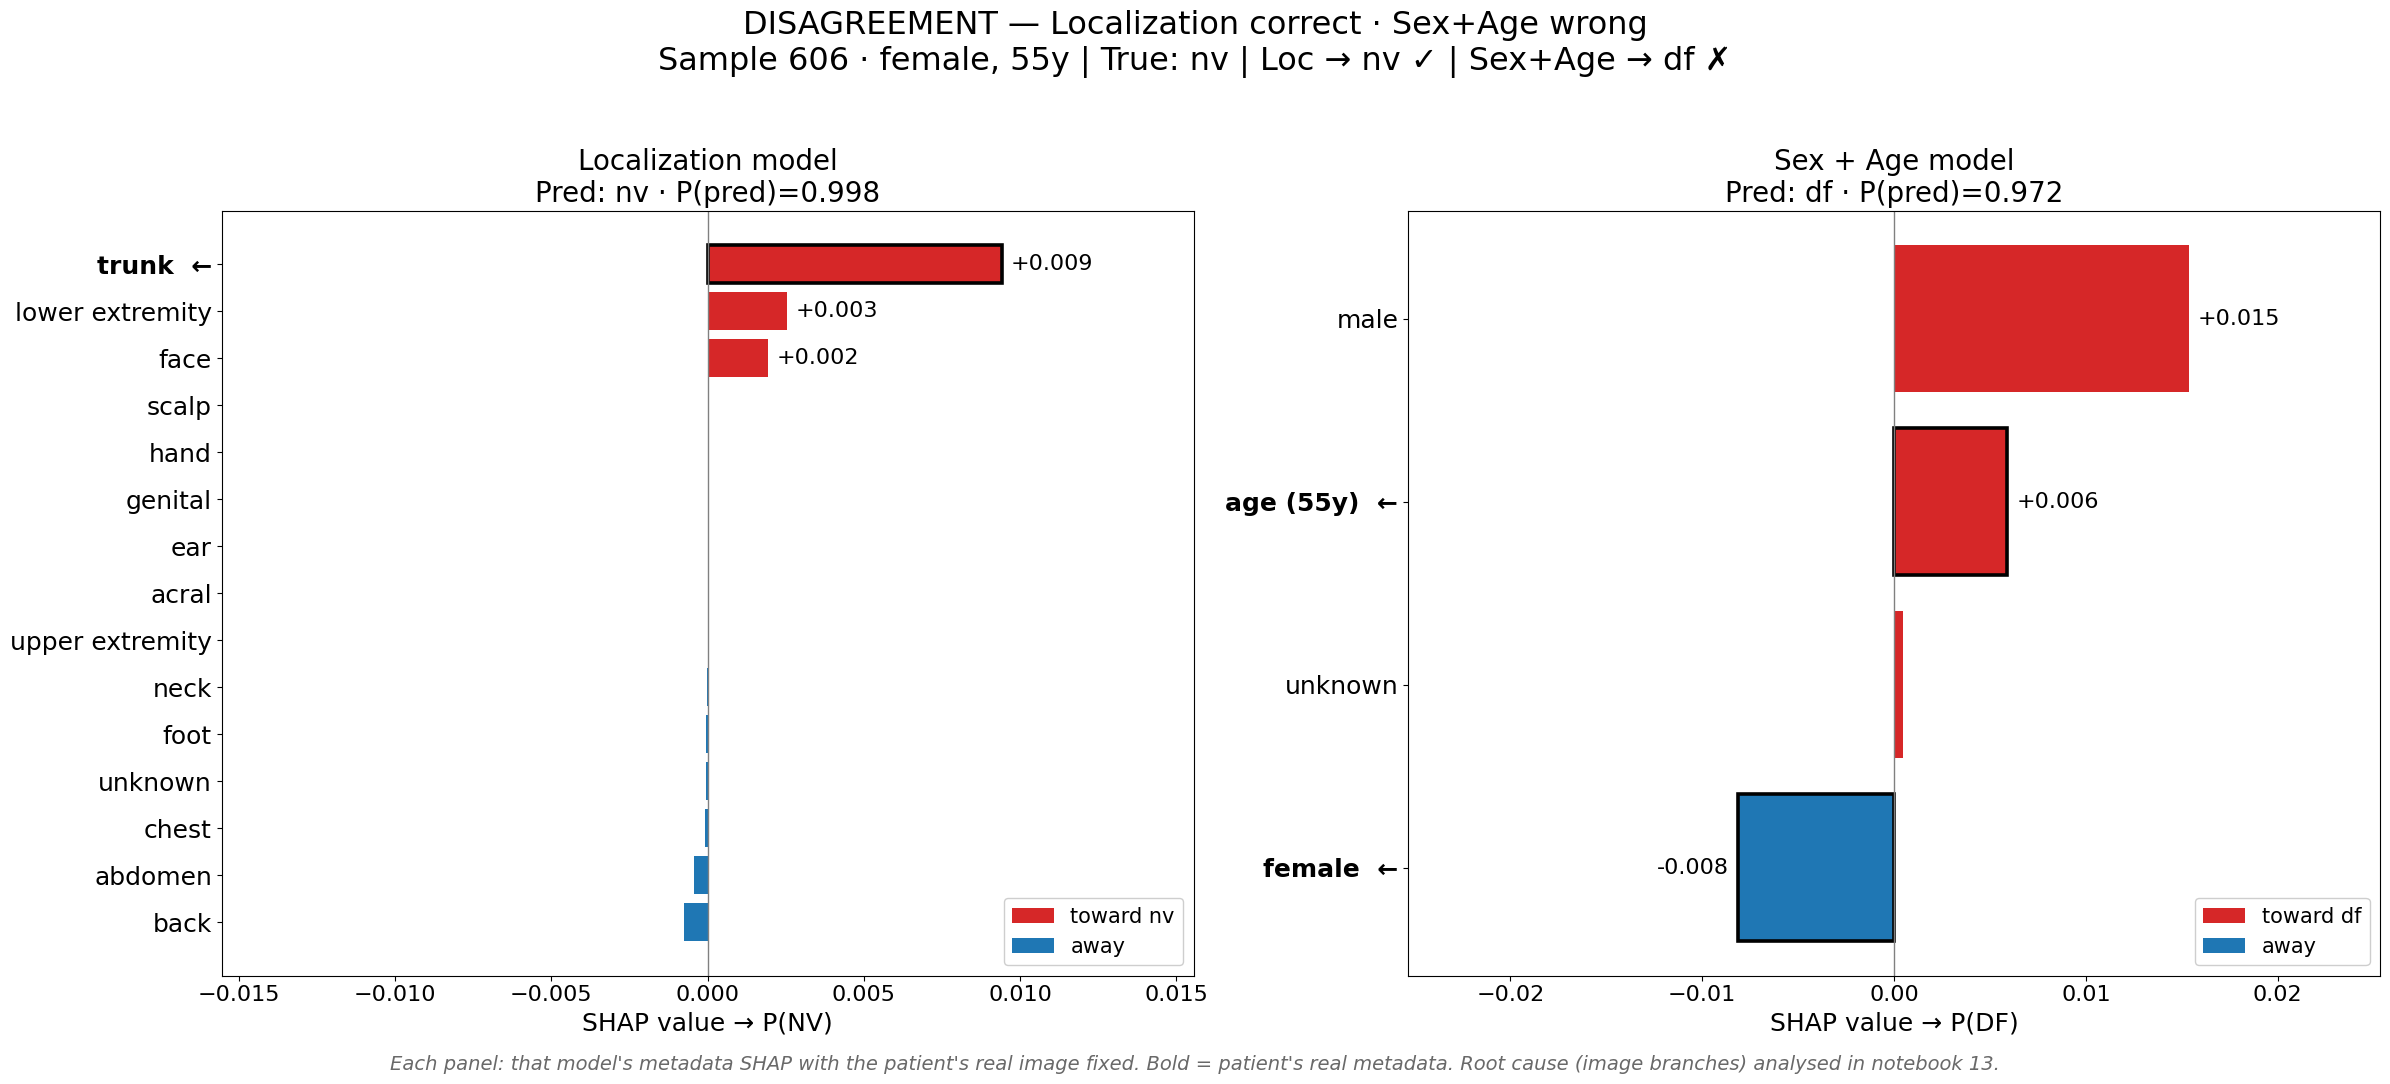

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_disagreement_loc_wins.png


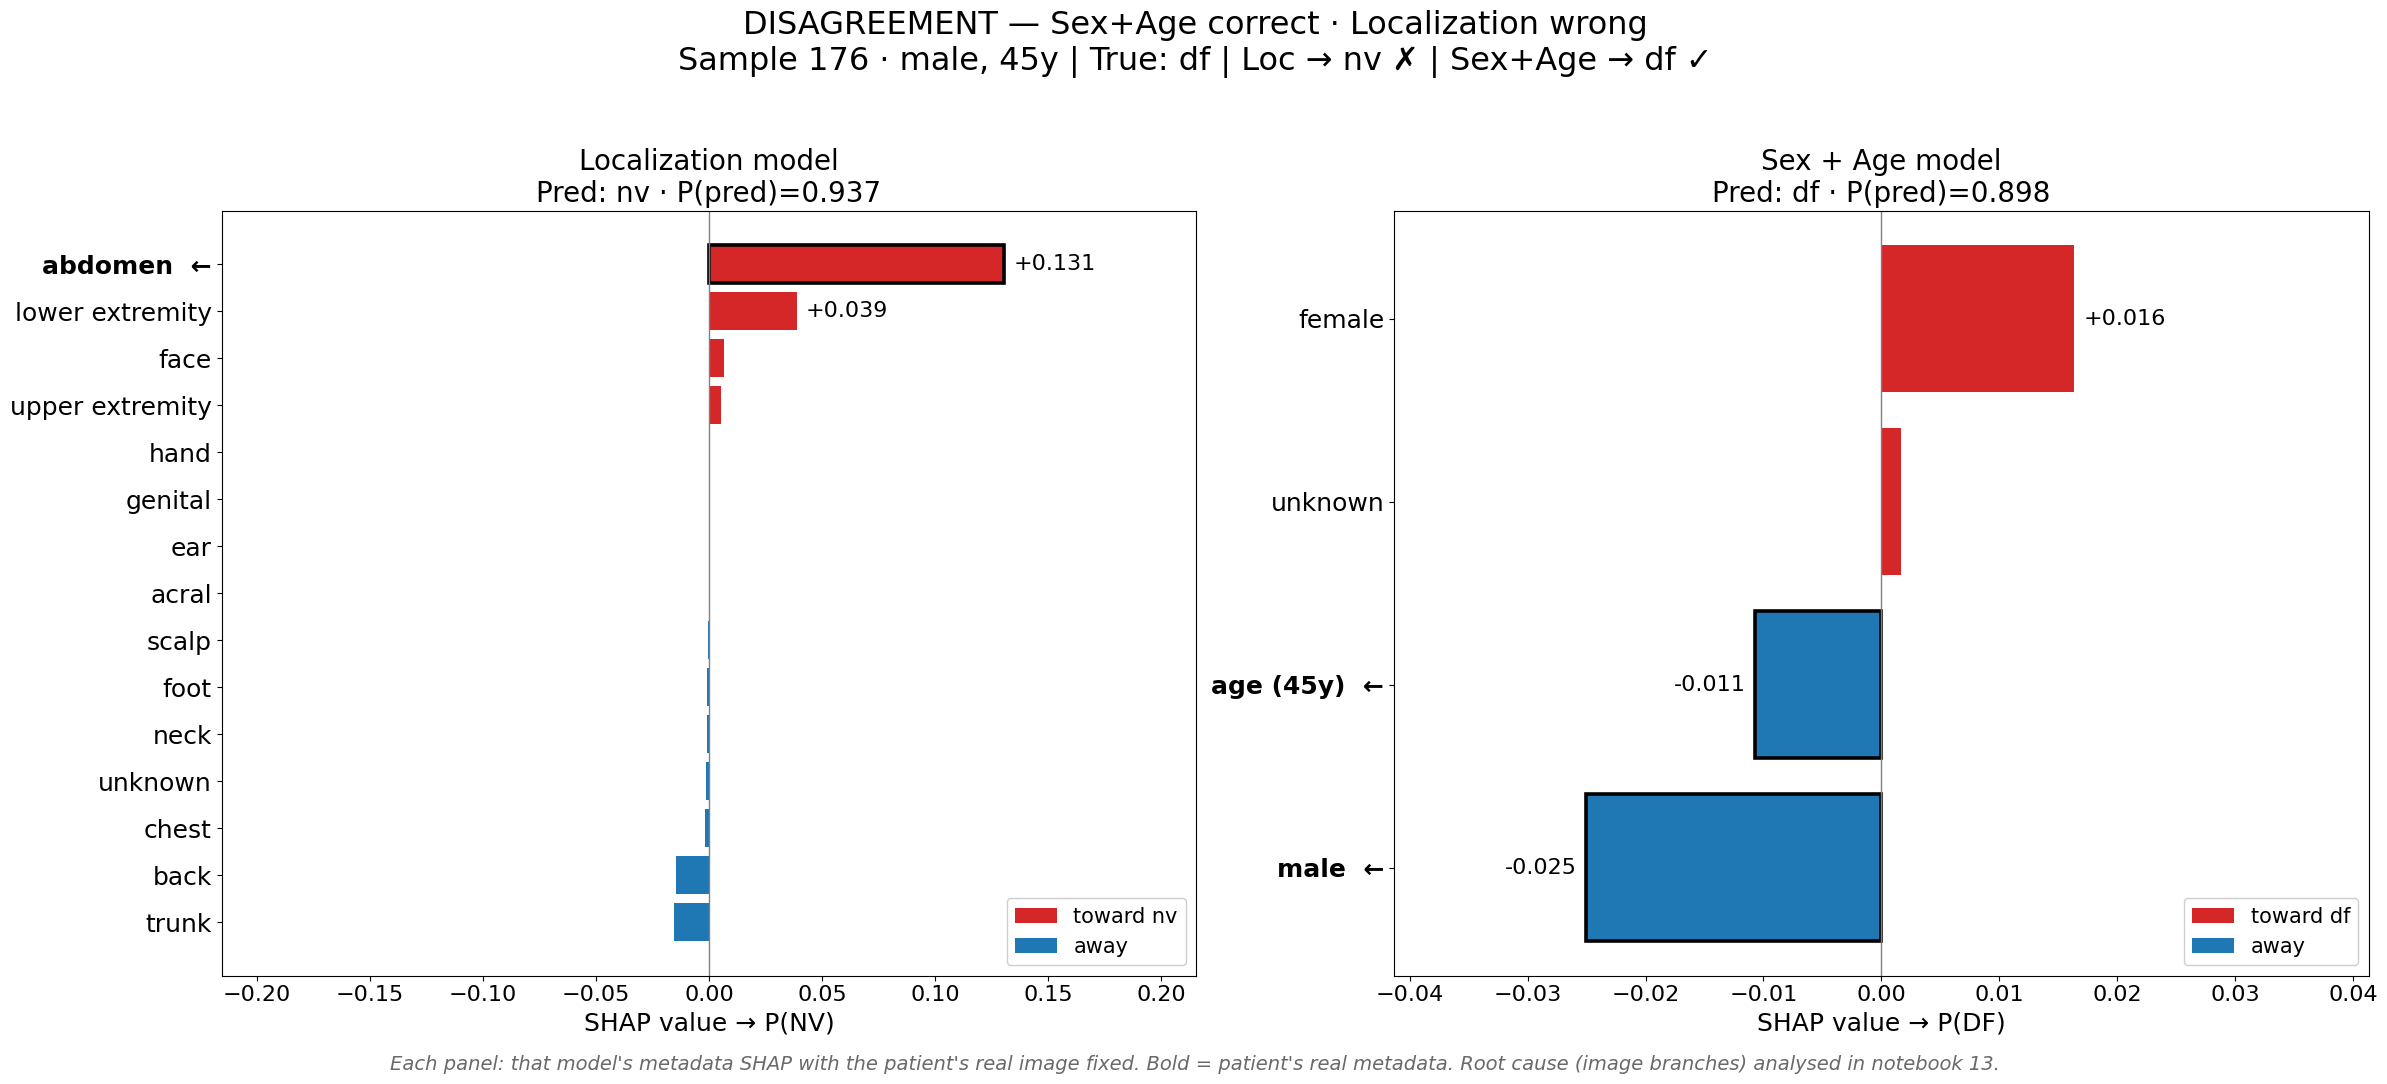

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_disagreement_sa_wins.png


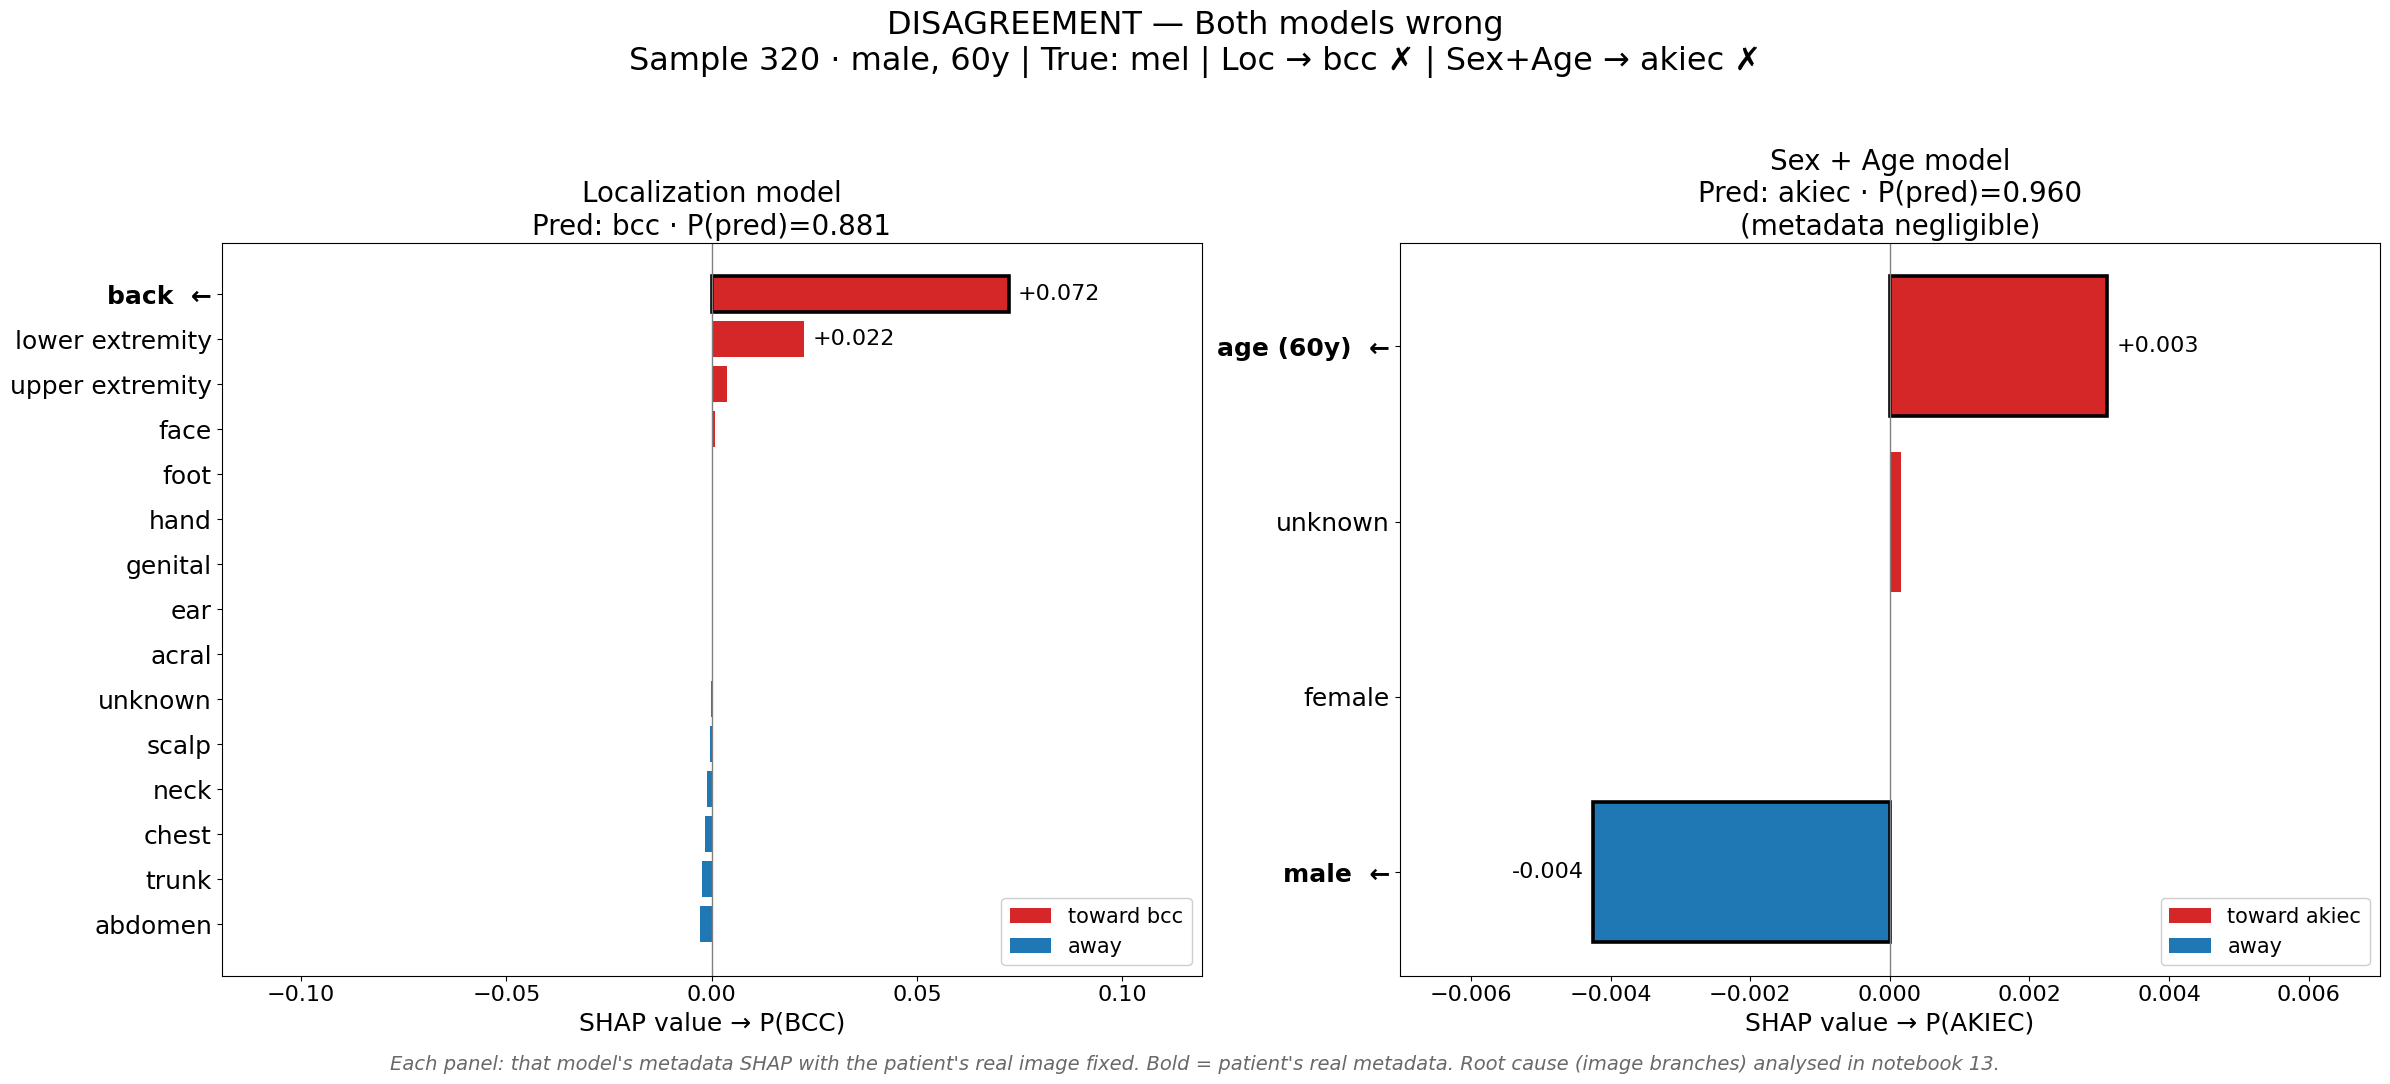

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_disagreement_both_wrong.png


In [54]:
# ── Side-by-side disagreement figure (localization vs sex_age) — thesis-ready ─
from matplotlib.patches import Patch

AGE_SCALE = 90.0   # age in metadata is normalized as real_age / 90


def _draw_model_panel(ax, idx, model, img_features, metadata, background,
                      feat_names, model_name, pred_idx, highlight_idxs):
    """highlight_idxs: list of feature indices to bold (the patient's real metadata)."""
    pred = CLASSES[pred_idx]
    sv, base, fx = shap_case_real_image(
        idx, pred_idx, model, img_features, metadata, background, device)

    # Show the patient's real age on the 'age' feature label
    disp_names = list(feat_names)
    if 'age' in feat_names:
        aj = feat_names.index('age')
        disp_names[aj] = f'age ({int(round(metadata[idx, aj] * AGE_SCALE))}y)'

    order  = np.argsort(sv)
    vals   = sv[order]
    names  = [disp_names[i] for i in order]
    hl_pos = set(list(order).index(h) for h in highlight_idxs)   # positions to bold
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in vals]

    bars = ax.barh(range(len(vals)), vals, color=colors)
    ax.axvline(0, color='gray', lw=1.0)
    for p in hl_pos:
        bars[p].set_edgecolor('black'); bars[p].set_linewidth(2.6)

    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels([f'{n}  ←' if i in hl_pos else n
                        for i, n in enumerate(names)], fontsize=18)
    for i, lbl in enumerate(ax.get_yticklabels()):
        if i in hl_pos:
            lbl.set_fontweight('bold')

    xmax = max(np.max(np.abs(vals)), 1e-9)
    ax.set_xlim(-xmax * 1.65, xmax * 1.65)
    for i, v in enumerate(vals):
        if abs(v) >= xmax * 0.12 or i in hl_pos:
            ax.text(v + np.sign(v) * xmax * 0.03, i, fmt_val(v),
                    va='center', ha='left' if v > 0 else 'right', fontsize=16)
    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
    ax.tick_params(axis='x', labelsize=16)

    neg = np.max(np.abs(sv)) < NEGLIGIBLE_CASE
    ax.set_title(f'{model_name}\nPred: {pred} · P(pred)={fx:.3f}'
                 + ('\n(metadata negligible)' if neg else ''), fontsize=20)
    ax.set_xlabel(f'SHAP value → P({pred.upper()})', fontsize=18)
    ax.legend(handles=[Patch(facecolor='#d62728', label=f'toward {pred}'),
                       Patch(facecolor='#1f77b4', label='away')],
              loc='lower right', fontsize=15, framealpha=0.95)


def plot_disagreement_case(idx, case_title, save_name):
    true = CLASSES[int(labels[idx])]
    lp, sp = int(loc_preds[idx]), int(sa_preds[idx])

    # Highlight sets = the patient's REAL metadata
    hl_loc = [int(np.argmax(metadata_loc[idx]))]                          # real location
    sex_cols   = [i for i, n in enumerate(SEX_AGE_FEATURE_NAMES) if n != 'age']
    active_sex = sex_cols[int(np.argmax(metadata_sa[idx, sex_cols]))]     # real sex
    age_idx    = SEX_AGE_FEATURE_NAMES.index('age')
    hl_sa = [active_sex, age_idx]                                         # real sex + age

    patient_sex = SEX_AGE_FEATURE_NAMES[active_sex]
    patient_age = int(round(metadata_sa[idx, age_idx] * AGE_SCALE))

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(24, 10))
    _draw_model_panel(axL, idx, model_loc, img_features_loc, metadata_loc,
                      background_loc, LOC_FEATURE_NAMES, 'Localization model', lp, hl_loc)
    _draw_model_panel(axR, idx, model_sa, img_features_sa, metadata_sa,
                      background_sa, SEX_AGE_FEATURE_NAMES, 'Sex + Age model', sp, hl_sa)

    lc = '✓' if lp == int(labels[idx]) else '✗'
    sc = '✓' if sp == int(labels[idx]) else '✗'
    fig.suptitle(f'DISAGREEMENT — {case_title}\n'
                 f'Sample {idx} · {patient_sex}, {patient_age}y | True: {true} | '
                 f'Loc → {CLASSES[lp]} {lc} | Sex+Age → {CLASSES[sp]} {sc}',
                 fontsize=23, y=1.04)
    fig.text(0.5, -0.02,
             "Each panel: that model's metadata SHAP with the patient's real image fixed. "
             "Bold = patient's real metadata. Root cause (image branches) analysed in notebook 13.",
             ha='center', fontsize=14, style='italic', color='dimgray')

    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, save_name)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


tag_map = {'Localization correct · Sex+Age wrong': 'loc_wins',
           'Sex+Age correct · Localization wrong': 'sa_wins',
           'Both models wrong':                    'both_wrong'}

for case_title, idx in disagreement_cases.items():
    plot_disagreement_case(idx, case_title, f'shap_disagreement_{tag_map[case_title]}.png')

## Part 4 — Age dependence (sex_age model)

Localization is one-hot (weak signal). The `sex_age` model carries the strongest
clinical metadata signal: **age** (continuous, r=−0.428 with diagnosis in the EDA).
A SHAP **dependence plot** shows the relationship the model learned between patient
age and each diagnosis: for every patient, the real age (x-axis) vs the SHAP value
of age (y-axis). Image is fixed at the dataset mean (the per-patient version is
deferred to notebook 13).

In [56]:
# ── SHAP for model_sa on ALL test samples (needed for the age dependence plot) ─
# Only 4 metadata features → fast (KernelExplainer is near-exact here).
print('Computing SHAP values for model_sa on all 1497 samples...')
shap_values_sa_all = explainer_sa.shap_values(metadata_sa, silent=False)

# Normalize to list-of-classes (robust across shap versions)
if not isinstance(shap_values_sa_all, list):
    shap_values_sa_all = [shap_values_sa_all[:, :, c] for c in range(shap_values_sa_all.shape[2])]

print(f'shap_values_sa_all: {len(shap_values_sa_all)} classes, '
      f'each {shap_values_sa_all[0].shape}')   # 7 × (1497, 4)

Computing SHAP values for model_sa on all 1497 samples...


100%|██████████| 1497/1497 [00:25<00:00, 59.76it/s]

shap_values_sa_all: 7 classes, each (1497, 4)


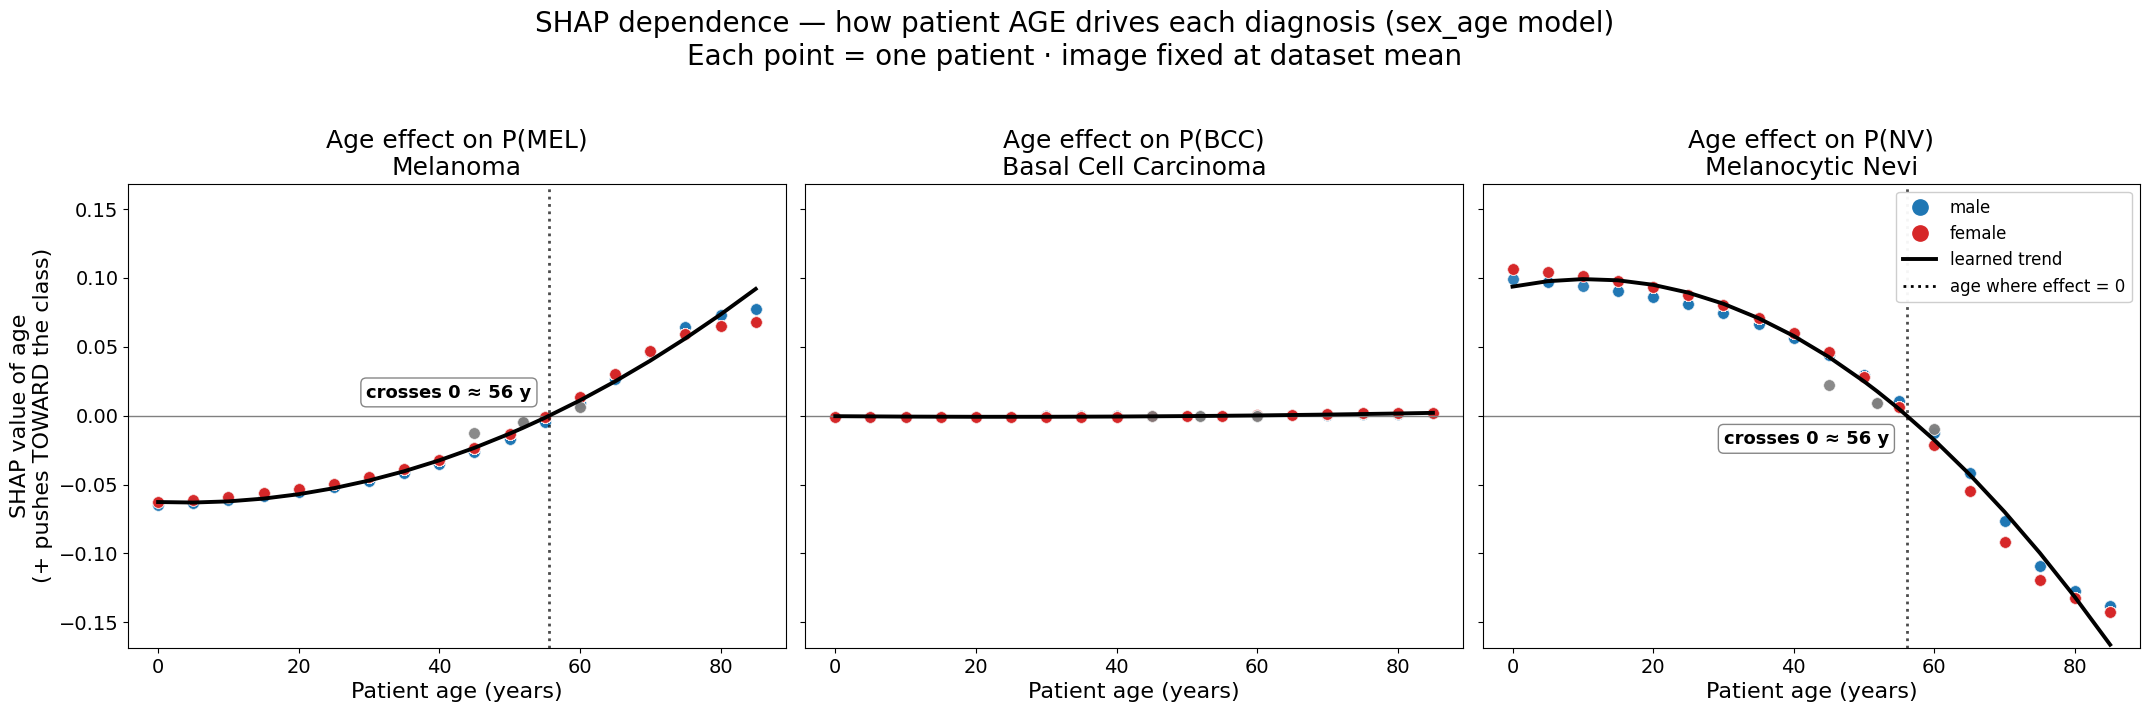

Saved: /home/maialen/skin_lesion_PFG/outputs/figures/shap_age_dependence.png


In [65]:
# ── SHAP dependence plot — age effect per class (sex_age model) ───────────────
from matplotlib.lines import Line2D

def age_dependence_plot(classes_to_plot, save_name):
    age_idx   = SEX_AGE_FEATURE_NAMES.index('age')
    real_age  = metadata_sa[:, age_idx] * AGE_SCALE              # back to real years
    sex_all   = np.argmax(metadata_sa[:, :3], axis=1)            # 0=male,1=female,2=unknown
    sex_color = {0: '#1f77b4', 1: '#d62728', 2: '#7f7f7f'}
    sex_name  = {0: 'male',    1: 'female',  2: 'unknown'}

    n = len(classes_to_plot)
    fig, axes = plt.subplots(1, n, figsize=(7.2 * n, 6.8), sharey=True)
    if n == 1:
        axes = [axes]

    # Shared y-scale so slopes are comparable across classes
    allv = np.concatenate([shap_values_sa_all[CLASS_TO_IDX[c]][:, age_idx] for c in classes_to_plot])
    ymax = np.max(np.abs(allv)) * 1.18

    for ax, c in zip(axes, classes_to_plot):
        sv_age = shap_values_sa_all[CLASS_TO_IDX[c]][:, age_idx]
        for s in [0, 1, 2]:
            m = sex_all == s
            if m.sum() == 0:
                continue
            ax.scatter(real_age[m], sv_age[m], s=70, alpha=0.7,
                       color=sex_color[s], edgecolors='white', linewidths=0.5,
                       label=sex_name[s])
        ax.axhline(0, color='gray', lw=1.0)

        # Learned trend (degree-2 fit)
        o = np.argsort(real_age)
        z = np.polyfit(real_age, sv_age, 2)
        ax.plot(real_age[o], np.polyval(z, real_age[o]), color='black', lw=2.8)

        # Zero-crossing (inflection age) — only annotate if the panel is not flat
        if np.max(np.abs(sv_age)) > 0.02:
            roots = np.roots(z)
            roots = roots[np.isreal(roots)].real
            inr   = roots[(roots >= real_age.min()) & (roots <= real_age.max())]
            if len(inr) > 0:
                cross = inr[np.argmin(np.abs(inr - np.median(real_age)))]
                ax.axvline(cross, color='black', ls=':', lw=2.0, alpha=0.7)
                xr = real_age.max() - real_age.min()
                # nudge label up if the trend rises, down if it falls
                slope_at_cross = 2 * z[0] * cross + z[1]      # derivative of the deg-2 fit
                y_off = ymax * 0.10 if slope_at_cross > 0 else -ymax * 0.10
                ax.annotate(f'crosses 0 ≈ {cross:.0f} y', xy=(cross, y_off),
                            xytext=(cross - xr * 0.03, y_off), ha='right', va='center',
                            fontsize=13, fontweight='bold',
                            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.95))

        ax.set_ylim(-ymax, ymax)
        ax.set_title(f'Age effect on P({c.upper()})\n{CLASS_NAMES_FULL[c]}', fontsize=18)
        ax.set_xlabel('Patient age (years)', fontsize=16)
        ax.tick_params(labelsize=14)

    axes[0].set_ylabel('SHAP value of age\n(+ pushes TOWARD the class)', fontsize=16)

    handles = [Line2D([0], [0], marker='o', ls='', color='#1f77b4', label='male',   ms=11),
               Line2D([0], [0], marker='o', ls='', color='#d62728', label='female', ms=11),
               Line2D([0], [0], color='black', lw=2.8, label='learned trend'),
               Line2D([0], [0], color='black', ls=':', lw=2.0, label='age where effect = 0')]
    # Legend INSIDE the last panel, top-right
    axes[-1].legend(handles=handles, fontsize=12, framealpha=0.95, loc='upper right')

    fig.suptitle('SHAP dependence — how patient AGE drives each diagnosis (sex_age model)\n'
                 'Each point = one patient · image fixed at dataset mean', fontsize=20, y=1.04)
    plt.tight_layout()

    save_path = os.path.join(FIGURES_DIR, save_name)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


age_dependence_plot(['mel', 'bcc', 'nv'], 'shap_age_dependence.png')

## Summary of saved figures

All figures are saved to `FIGURES_DIR`.

| Part | File | Content |
|------|------|---------|
| 1 | `shap_localization_effect_melanoma.png` | Signed SHAP effect of each localization on P(melanoma) |
| 1 | `shap_global_bar.png` | Mean \|SHAP\| per localization (averaged over all classes) |
| 1 | `shap_localization_per_class_heatmap.png` | Signed localization effect per class (heatmap) |
| 2 | `shap_clinical_tp.png` | Clinical case — melanoma correctly detected (TP) |
| 2 | `shap_clinical_fn.png` | Clinical case — melanoma missed (FN, critical error) |
| 2 | `shap_clinical_fp.png` | Clinical case — benign predicted as melanoma (FP) |
| 2 | `shap_clinical_tn.png` | Clinical case — benign correctly ruled out (TN) |
| 3 | `shap_disagreement_loc_wins.png` | Disagreement — localization correct, sex_age wrong |
| 3 | `shap_disagreement_sa_wins.png` | Disagreement — sex_age correct, localization wrong |
| 3 | `shap_disagreement_both_wrong.png` | Disagreement — both models wrong |
| 4 | `shap_age_dependence.png` | SHAP dependence of age on P(mel)/P(bcc)/P(nv) |